This script includes the CNN based network to train, quantize and compile the model used for MyoWare-based gesture classification. The EMG data was acquired using 2x MyoWare 2.0 sensors with a sampling frequency of 200Hz, placed on the flexor and extensor muscles of the forearm.

Same structure as the labmate's `EMG-NET.ipynb`, adapted for 2 channels / 3 classes instead of 8 channels / 7 classes.

STEP 1: IMPORTING AND PRE-PROCESSING

In [1]:
import sys
import os

# bmis_gesture_utils.py lives in ../src, not in this Notebooks folder --
# this line tells Python to also look there when importing.
sys.path.append(os.path.join(os.getcwd(), "..", "src"))

import tensorflow as tf

import matplotlib.pyplot as plt
from tensorflow.keras import backend as K
# from tensorflow_model_optimization.quantization.keras import vitis_quantize
# ^ commented out for now -- this only exists inside the Vitis-AI Docker container,
#   not in this laptop's regular Python environment. We'll uncomment this and switch
#   to running inside that container once we reach the quantization step.
from tensorflow.keras.utils import plot_model

from bmis_gesture_utils import *

import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn import metrics
from sklearn.metrics import classification_report
import matplotlib

2026-08-18 01:52:18.072067: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-18 01:52:18.092928: I tensorflow/core/platform/cpu_feature_guard.cc:186] This TensorFlow binary is optimized with Zen Deep Neural Network Library (ZenDNN) to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
no_gesture = 3      # REST, CLOSE, OPEN -- his value was 7
fs = 200

# His notch_freq / quality_factor / fc / fh / order are not here on purpose --
# those control filtering for the Myo armband's raw signal. MyoWare already
# filters/rectifies in hardware, so that step doesn't apply to our data.

window_time = 200
overlap = 50
no_channel = 2       # his value was 8

His notebook processes one subject at a time (`subject = 12`). We have 2 subjects, so we call `get_data_subject_specific` once per subject and stack the results together.

In [3]:
X1, y1 = get_data_subject_specific(subject=1, no_gesture=no_gesture, fs=fs,
                                    window_time=window_time, overlap=overlap, no_channel=no_channel)
X2, y2 = get_data_subject_specific(subject=2, no_gesture=no_gesture, fs=fs,
                                    window_time=window_time, overlap=overlap, no_channel=no_channel)

data = np.row_stack((X1, X2))
label = np.row_stack((y1, y2))

print('The total data shape is {} and label is {}'.format(data.shape, label.shape))

The total data shape is (4398, 2, 40) and label is (4398, 1)


In [4]:
np.unique(label)

array([0., 1., 2.])

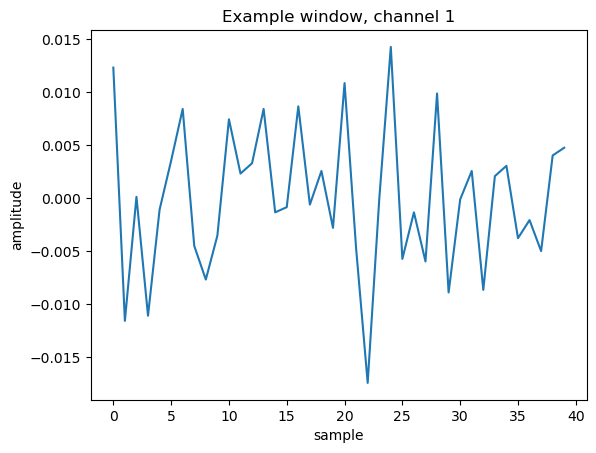

In [5]:
# His notebook uses get_time_domain_plot() from biosignal_analysis_tools.py.
# We don't have that file, so this is a plain matplotlib version doing the same job:
# plotting one window of raw signal so you can see what the data actually looks like.
plt.plot(data[0, 0, :])
plt.title('Example window, channel 1')
plt.xlabel('sample')
plt.ylabel('amplitude')
plt.show()

In [6]:
gesture_list = ['REST', 'CLOSE', 'OPEN']

In [7]:
X_train, y_train, X_test, y_test = spilt_data(data, label, ratio=0.1)
print('Training Set is {} Test Set {}'.format(X_train.shape, X_test.shape))

Training Set is (3958, 2, 40) Test Set (440, 2, 40)


In [8]:
# Expanding the input feature shape

X_train = np.expand_dims(X_train, axis=3)
X_test = np.expand_dims(X_test, axis=3)
print('Expanded Dimension are {}'.format(X_train.shape))
input_size = X_train.shape[1:]
print(input_size)

Expanded Dimension are (3958, 2, 40, 1)
(2, 40, 1)


STEP 2: TRAINING AND HYPER-PARAMETER TUNING

His model, for reference (`EMG-NET.ipynb`):
```python
def emg_net():
    inputs = tf.keras.Input(shape=input_size)
    x = tf.keras.layers.Conv2D(32, 3, activation="relu", input_shape=input_size)(inputs)
    x = tf.keras.layers.Conv2D(32, 3, activation="relu")(x)
    x = tf.keras.layers.MaxPool2D((2,2))(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(151, activation='relu')(x)
    outputs = tf.keras.layers.Dense(7, activation='softmax')(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="BMIS-EMG-NET")
    return model
```

His `input_size` is `(8, 40, 1)` -- 8 channels tall. A `Conv2D(32, 3)` uses a 3x3 kernel, which fits fine on a height of 8.

Ours is `(2, 40, 1)` -- only 2 channels tall. A 3-tall kernel cannot fit on a height of 2 at all (TensorFlow will throw a shape error). This is the one forced change: kernel *height* had to shrink to fit our channel count. Everything else -- filter counts (32), number of conv layers (2), dropout rate (0.5), dense layer size (151) -- is kept identical to his, since none of those are forced by our data shape, only chosen by him as reasonable defaults that still work fine for us.

In [9]:
def gesture_net():

    inputs = tf.keras.Input(shape=input_size)
    x = tf.keras.layers.Conv2D(32, (2, 3), activation="relu", input_shape=input_size)(inputs)  # kernel height 3->2, forced (only 2 channels)
    x = tf.keras.layers.Conv2D(32, (1, 3), activation="relu")(x)  # kernel height 3->1, forced (height is already 1 after the first conv)
    x = tf.keras.layers.MaxPool2D((1, 2))(x)  # pool height 2->1, forced (can't pool a dimension of size 1 by 2)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(151, activation='relu')(x)
    outputs = tf.keras.layers.Dense(3, activation='softmax')(x)  # 7->3, forced (REST/CLOSE/OPEN instead of 7 gestures)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="BMIS-GESTURE-NET")

    return model

In [10]:
model = gesture_net()
model.summary()

Model: "BMIS-GESTURE-NET"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 2, 40, 1)]        0         
                                                                 
 conv2d (Conv2D)             (None, 1, 38, 32)         224       
                                                                 
 conv2d_1 (Conv2D)           (None, 1, 36, 32)         3104      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 1, 18, 32)        0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 1, 18, 32)         0         
                                                                 
 flatten (Flatten)           (None, 576)               0         
                                                  

Now the actual training loop, matching his structure: Adam optimizer, 3-fold cross-validation, early stopping, saving the best model.

Two things had to change from his exact code -- not because of our data, but because his notebook was written for an older version of TensorFlow/Keras than what's on this laptop:
1. `ModelCheckpoint(filepath=checkpoint_path, ...)` -- his `checkpoint_path` is a bare folder path. Newer Keras requires the filename to end in `.keras` or `.h5`, so we add a filename onto the end.
2. `metrics=mtr` where `mtr = 'accuracy'` -- his code passes a plain string. Newer Keras requires a list, so we use `metrics=['accuracy']`.

Also fixed a likely typo in his code: `vebrose=1` (misspelled) -> `verbose=1`.

In [11]:
lr = 0.001
opt = tf.keras.optimizers.Adam(learning_rate=lr, epsilon=1e-07, clipnorm=1)
ls = 'sparse_categorical_crossentropy'
mtr = ['accuracy']    # his version: mtr = 'accuracy' -- wrapped in a list, required by newer Keras

n_batches = 16
n_epochs = 30
early_stop = tf.keras.callbacks.EarlyStopping(monitor='accuracy', patience=5)

checkpoint_dir = os.path.join('..', 'checkpoint', 'full', 'subjects_1_2')  # his version used str(subject) -- we don't have a single subject, so 'subjects_1_2'
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)
checkpoint_path = os.path.join(checkpoint_dir, 'best_model.keras')  # his version: checkpoint_path was a bare folder, no filename -- newer Keras requires a .keras/.h5 filename

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
                            filepath=checkpoint_path, save_best_only=True, monitor='accuracy', verbose=1)

num_folds = 3
fold_no = 1
kfold = KFold(n_splits=num_folds, shuffle=False)
accuracy_per_fold = []
loss_per_fold = []

In [12]:
for train, test in kfold.split(X_train, y_train):

    model = gesture_net()
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr, epsilon=1e-07, clipnorm=1), loss=ls, metrics=mtr)
    # ^ fresh optimizer created here each fold, instead of reusing `opt` from the earlier cell.
    #   Reusing one optimizer object across multiple freshly-built models isn't allowed by
    #   this TensorFlow version -- it errors on the 2nd fold because the new model's variables
    #   don't match what the optimizer was already tracking from fold 1.

    print('---------------------------------------------------')
    print(f'Training for fold {fold_no} -------')

    history = model.fit(X_train[train], y_train[train], callbacks=[early_stop, checkpoint_callback],
                        batch_size=n_batches, epochs=n_epochs, verbose=1)

    scores = model.evaluate(X_train[test], y_train[test], verbose=0)
    print(f'Score for fold  {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]*100}%')
    accuracy_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])

    fold_no = fold_no + 1


---------------------------------------------------
Training for fold 1 -------
Epoch 1/30
150/165 [==========================>...] - ETA: 0s - loss: 0.8675 - accuracy: 0.5954
Epoch 1: accuracy improved from -inf to 0.61600, saving model to ../checkpoint/full/subjects_1_2/best_model.keras
165/165 [==============================] - 1s 4ms/step - loss: 0.8293 - accuracy: 0.6160
Epoch 2/30
160/165 [============================>.] - ETA: 0s - loss: 0.4064 - accuracy: 0.8313
Epoch 2: accuracy improved from 0.61600 to 0.83321, saving model to ../checkpoint/full/subjects_1_2/best_model.keras
165/165 [==============================] - 0s 3ms/step - loss: 0.4046 - accuracy: 0.8332
Epoch 3/30
153/165 [==========================>...] - ETA: 0s - loss: 0.2965 - accuracy: 0.8979
Epoch 3: accuracy improved from 0.83321 to 0.89651, saving model to ../checkpoint/full/subjects_1_2/best_model.keras
165/165 [==============================] - 0s 3ms/step - loss: 0.3019 - accuracy: 0.8965
Epoch 4/30
150/16

In [13]:
print("Average Score per fold ")

for i in range(0, len(accuracy_per_fold)):
    print('-----------------------------------------------')
    print(f'> Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {accuracy_per_fold[i]}%')
print('-----------------------------------------------')
print('Average Metrics for all folds: ')
print(f'> Accuracy: {np.mean(accuracy_per_fold)} (+- {np.std(accuracy_per_fold)})')
print(f'> Loss: {np.mean(loss_per_fold)}')
print('-----------------------------------------------')

Average Score per fold 
-----------------------------------------------
> Fold 1 - Loss: 0.13259300589561462 - Accuracy: 95.53030133247375%
-----------------------------------------------
> Fold 2 - Loss: 0.16845951974391937 - Accuracy: 93.85898113250732%
-----------------------------------------------
> Fold 3 - Loss: 0.14992986619472504 - Accuracy: 94.76876258850098%
-----------------------------------------------
Average Metrics for all folds: 
> Accuracy: 94.71934835116069 (+- 0.683207693088468)
> Loss: 0.15032746394475302
-----------------------------------------------


In [14]:
validation_result = np.mean(accuracy_per_fold)
print(f'The three-fold cross validation result is: {validation_result}%')

The three-fold cross validation result is: 94.71934835116069%


In [15]:
# Load the best checkpoint saved during training
model = tf.keras.models.load_model(checkpoint_path)

In [16]:
uqt_test_loss, uqt_test_accuracy = model.evaluate(X_test, y_test)
full_test_accuracy = uqt_test_accuracy * 100
print(f'Accuracy of the Unquantized_model {full_test_accuracy}%')

14/14 [==============================] - 0s 2ms/step - loss: 0.2226 - accuracy: 0.9364
Accuracy of the Unquantized_model 93.63636374473572%


In [17]:
saved_model_dir = os.path.join('..', 'Pretrained_Models', 'full_models')
os.makedirs(saved_model_dir, exist_ok=True)
saved_model = os.path.join(saved_model_dir, 'gesture-net-subjects_1_2.h5')
model.save(saved_model)
print(f'Saved to {saved_model}')


Saved to ../Pretrained_Models/full_models/gesture-net-subjects_1_2.h5


STEP 3: POST TRAINING QUANTIZATION (Int-8)

In [18]:
calibration_dataset = X_train[0:1000]  # Note a minimum of 100 is needed and a maximum of 1000
evaluation_dataset = X_test
evaluation_dataset_gnd = y_test


In [19]:
from tensorflow_model_optimization.quantization.keras import vitis_quantize

saved_float32_model = tf.keras.models.load_model(saved_model)
ptq_quantizer = vitis_quantize.VitisQuantizer(saved_float32_model)
ptq_quantized_model = ptq_quantizer.quantize_model(calib_dataset=calibration_dataset)



[VAI INFO] Using func format quantizer
[VAI INFO] Quantizing without specific `target`.
[VAI INFO] Start CrossLayerEqualization...
10/10 [==============================] - 1s 63ms/step
[VAI INFO] CrossLayerEqualization Done.
[VAI INFO] Start Quantize Calibration...
32/32 [==============================] - 1s 7ms/step
[VAI INFO] Quantize Calibration Done.
[VAI INFO] Start Post-Quant Model Refinement...
[VAI INFO] Start Quantize Position Ajustment...
[VAI INFO] Quantize Position Ajustment Done.
[VAI INFO] Post-Quant Model Refninement Done.
[VAI INFO] Start Model Finalization...
[VAI INFO] Model Finalization Done.
[VAI INFO] Quantization Finished.


In [20]:
# Evaluating Post training quantization

ptq_quantized_model.compile(loss=ls, metrics=mtr)
ptq_loss, ptq_accuracy = ptq_quantized_model.evaluate(evaluation_dataset, evaluation_dataset_gnd)
ptq_test_accuracy = ptq_accuracy * 100
print(f'Post training quantization accuracy {ptq_test_accuracy}%')

# Saving post training quantization
ptq_model_dir = os.path.join('..', 'Pretrained_Models', 'ptq_models')
os.makedirs(ptq_model_dir, exist_ok=True)
quantized_model = os.path.join(ptq_model_dir, 'ptq-gesture-net-subjects_1_2.h5')
ptq_quantized_model.save(quantized_model)
print(f'Saved to {quantized_model}')


14/14 [==============================] - 0s 3ms/step - loss: 0.2176 - accuracy: 0.9409
Post training quantization accuracy 94.09090876579285%
Saved to ../Pretrained_Models/ptq_models/ptq-gesture-net-subjects_1_2.h5


In [21]:
!PATH=/opt/vitis_ai/conda/envs/vitis-ai-tensorflow2/bin:$PATH vai_c_tensorflow2 --model ../Pretrained_Models/ptq_models/ptq-gesture-net-subjects_1_2.h5 --arch ../src/arch_ultra96.json --output_dir ../compiled_output --net_name gesture_model_compiled


**************************************************
* VITIS_AI Compilation - Xilinx Inc.
**************************************************
[INFO] Namespace(batchsize=1, inputs_shape=None, layout='NHWC', model_files=['../Pretrained_Models/ptq_models/ptq-gesture-net-subjects_1_2.h5'], model_type='tensorflow2', named_inputs_shape=None, out_filename='/tmp/gesture_model_compiled_0x101000016010404_org.xmodel', proto=None)
[INFO] tensorflow2 model: /workspace/Pretrained_Models/ptq_models/ptq-gesture-net-subjects_1_2.h5
[INFO] keras version: 2.12.0
[INFO] Tensorflow Keras model type: functional
[INFO] generate xmodel     :100%|█| 21/21 [00:00<00:00, 2827.44it/s]            
[INFO] dump xmodel: /tmp/gesture_model_compiled_0x101000016010404_org.xmodel
[UNILOG][INFO] Compile mode: dpu
[UNILOG][INFO] Debug mode: null
[UNILOG][INFO] Target architecture: DPUCZDX8G_ISA1_B1600_0101000016010404
[UNILOG][INFO] Graph name: BMIS-GESTURE-NET, with op num: 33
[UNILOG][INFO] Begin to compile...
[UNILOG][INFO